In [ ]:
!pip install -q kagglehub nibabel segmentation-models

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.7/50.7 kB 1.6 MB/s eta 0:00:00


In [ ]:
import os
import cv2
import glob
import random
import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib
import tensorflow as tf

from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
import kagglehub

path = kagglehub.dataset_download(
    "awsaf49/brats20-dataset-training-validation"
)

print(path)

Using Colab cache for faster access to the 'brats20-dataset-training-validation' dataset.
/kaggle/input/brats20-dataset-training-validation


In [ ]:
flair_list = glob.glob(
    path + "/**/*_flair.nii",
    recursive=True
)

training_images = []

for image_path in flair_list:

    mask_path = image_path.replace(
        "_flair.nii",
        "_seg.nii"
    )

    if os.path.exists(mask_path):
        training_images.append(image_path)

flair_list = training_images

print("Training Images:", len(flair_list))

Training Images: 368


In [ ]:
IMG_SIZE = 128

image_dataset = []
mask_dataset = []

LIMIT = 1500

for image_path in flair_list[:LIMIT]:

    mask_path = image_path.replace(
        "_flair.nii",
        "_seg.nii"
    )

    # MRI
    image = nib.load(image_path).get_fdata()

    # Mask
    mask = nib.load(mask_path).get_fdata()

    # Middle slice
    slice_x = image.shape[2] // 2

    image = image[:, :, slice_x]
    mask = mask[:, :, slice_x]

    # Resize
    image = cv2.resize(
        image,
        (IMG_SIZE, IMG_SIZE)
    )

    mask = cv2.resize(
        mask,
        (IMG_SIZE, IMG_SIZE),
        interpolation=cv2.INTER_NEAREST
    )

    # Normalize
    image = image / np.max(image)

    # Binary Mask
    mask[mask > 0] = 1

    # Convert RGB
    image = np.stack(
        (image,)*3,
        axis=-1
    )

    image_dataset.append(image)
    mask_dataset.append(mask)

print("Done")

Done


In [ ]:
X = np.array(image_dataset)
y = np.array(mask_dataset)

y = np.expand_dims(y, axis=-1)

print(X.shape)
print(y.shape)

(368, 128, 128, 3)
(368, 128, 128, 1)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from tensorflow.keras.applications import MobileNetV2

# =========================
# Encoder
# =========================

base_model = MobileNetV2(
    input_shape=(128,128,3),
    include_top=False,
    weights='imagenet'
)

# Layers
layer_names = [
    'block_1_expand_relu',
    'block_3_expand_relu',
    'block_6_expand_relu',
    'block_13_expand_relu',
    'block_16_project'
]

layers_output = [
    base_model.get_layer(name).output
    for name in layer_names
]

down_stack = tf.keras.Model(
    inputs=base_model.input,
    outputs=layers_output
)

down_stack.trainable = False

# =========================
# Decoder
# =========================

up_stack = [
    tf.keras.layers.Conv2DTranspose(
        512, 3,
        strides=2,
        padding='same',
        activation='relu'
    ),

    tf.keras.layers.Conv2DTranspose(
        256, 3,
        strides=2,
        padding='same',
        activation='relu'
    ),

    tf.keras.layers.Conv2DTranspose(
        128, 3,
        strides=2,
        padding='same',
        activation='relu'
    ),

    tf.keras.layers.Conv2DTranspose(
        64, 3,
        strides=2,
        padding='same',
        activation='relu'
    )
]

# =========================
# U-Net
# =========================

inputs = tf.keras.layers.Input(
    shape=(128,128,3)
)

skips = down_stack(inputs)

x = skips[-1]

skips = reversed(skips[:-1])

for up, skip in zip(up_stack, skips):

    x = up(x)

    concat = tf.keras.layers.Concatenate()

    x = concat([x, skip])

# Final Layer
last = tf.keras.layers.Conv2DTranspose(
    1,
    3,
    strides=2,
    padding='same',
    activation='sigmoid'
)

x = last(x)

model = tf.keras.Model(inputs=inputs, outputs=x)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional          │ [(None, 64, 64,   │  1,841,984 │ input_layer_1[0]… │
│ (Functional)        │ 96), (None, 32,   │            │                   │
│                     │ 32, 144), (None,  │            │                   │
│                     │ 16, 16, 192),     │            │                   │
│                     │ (None, 8, 8,      │            │                   │
│                     │ 576), (None, 4,   │            │                   │
│                     │ 4, 320)]          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 8, 8, 512) │  1,475,072 │ functional[0][4]  │
│ (Conv2DTranspose)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 8, 8,      │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 1088)             │            │ functional[0][3]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_1  │ (None, 16, 16,    │  2,507,008 │ concatenate[0][0] │
│ (Conv2DTranspose)   │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 16, 16,    │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 448)              │            │ functional[0][2]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_2  │ (None, 32, 32,    │    516,224 │ concatenate_1[0]… │
│ (Conv2DTranspose)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 32, 32,    │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 272)              │            │ functional[0][1]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_3  │ (None, 64, 64,    │    156,736 │ concatenate_2[0]… │
│ (Conv2DTranspose)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 64, 64,    │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 160)              │            │ functional[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_4  │ (None, 128, 128,  │      1,441 │ concatenate_3[0]… │
│ (Conv2DTranspose)   │ 1)                │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 6,498,465 (24.79 MB)

 Trainable params: 4,656,481 (17.76 MB)

 Non-trainable params: 1,841,984 (7.03 MB)

In [ ]:
def dice_coef(y_true, y_pred, smooth=1):

    y_true_f = tf.keras.backend.flatten(y_true)

    y_pred_f = tf.keras.backend.flatten(y_pred)

    intersection = tf.keras.backend.sum(
        y_true_f * y_pred_f
    )

    return (
        2. * intersection + smooth
    ) / (
        tf.keras.backend.sum(y_true_f)
        + tf.keras.backend.sum(y_pred_f)
        + smooth
    )

def dice_loss(y_true, y_pred):

    return 1 - dice_coef(
        y_true,
        y_pred
    )

bce = tf.keras.losses.BinaryCrossentropy()

def total_loss(y_true, y_pred):

    return (
        bce(y_true, y_pred)
        + dice_loss(y_true, y_pred)
    )

In [ ]:
model.compile(
    optimizer='adam',
    loss=total_loss,
    metrics=[
        dice_coef,
        'accuracy'
    ]
)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.1,
    epochs=50,
    batch_size=4,
    callbacks=[early_stop]
)

Epoch 1/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 44s 514ms/step - accuracy: 0.9592 - dice_coef: 0.3676 - loss: 0.7554 - val_accuracy: 0.9839 - val_dice_coef: 0.6741 - val_loss: 0.3864
Epoch 2/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 31s 472ms/step - accuracy: 0.9855 - dice_coef: 0.7261 - loss: 0.3238 - val_accuracy: 0.9810 - val_dice_coef: 0.6584 - val_loss: 0.4066
Epoch 3/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 32s 486ms/step - accuracy: 0.9871 - dice_coef: 0.7559 - loss: 0.2918 - val_accuracy: 0.9885 - val_dice_coef: 0.7435 - val_loss: 0.3093
Epoch 4/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 31s 463ms/step - accuracy: 0.9894 - dice_coef: 0.7994 - loss: 0.2390 - val_accuracy: 0.9901 - val_dice_coef: 0.7745 - val_loss: 0.2679
Epoch 5/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 30s 454ms/step - accuracy: 0.9899 - dice_coef: 0.8028 - loss: 0.2340 - val_accuracy: 0.9877 - val_dice_coef: 0.7113 - val_loss: 0.3533
Epoch 6/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 32s 488ms/step - accuracy: 0.9909 - dice_coef: 0.8275 - loss: 0.2060 - val_accuracy: 0.9901 - val

In [ ]:
results = model.evaluate(
    X_test,
    y_test
)

print("Loss:", results[0])
print("IoU:", results[1])
print("F1 Score:", results[2])

3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 951ms/step - accuracy: 0.9907 - dice_coef: 0.7923 - loss: 0.2402
Loss: 0.2401866614818573
IoU: 0.7922974228858948
F1 Score: 0.9907177090644836


In [ ]:
preds = model.predict(X_test)

preds = (preds > 0.5).astype(np.uint8)

3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step


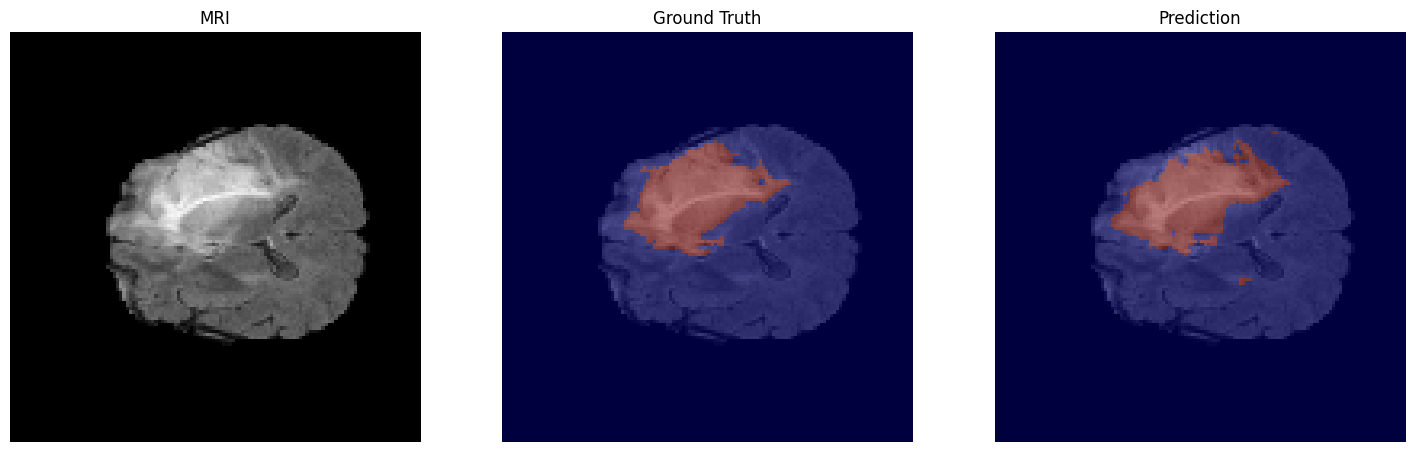

In [ ]:
index = random.randint(
    0,
    len(X_test)-1
)

img = X_test[index]

real_mask = y_test[index].squeeze()

pred_mask = preds[index].squeeze()

plt.figure(figsize=(18,6))

# MRI
plt.subplot(1,3,1)

plt.imshow(img[:,:,0], cmap='gray')

plt.title("MRI")

plt.axis("off")

# Ground Truth
plt.subplot(1,3,2)

plt.imshow(img[:,:,0], cmap='gray')

plt.imshow(
    real_mask,
    cmap='jet',
    alpha=0.5
)

plt.title("Ground Truth")

plt.axis("off")

# Prediction
plt.subplot(1,3,3)

plt.imshow(img[:,:,0], cmap='gray')

plt.imshow(
    pred_mask,
    cmap='jet',
    alpha=0.5
)

plt.title("Prediction")

plt.axis("off")

plt.show()

In [ ]:
model.save(
    "brain_tumor_segmentation.h5"
)

print("Model Saved")

Model Saved


In [ ]:
!pip install -q gradio

In [ ]:
%%writefile app.py

import gradio as gr
import numpy as np
import tensorflow as tf
import cv2

# ======================
# Load Model
# ======================

model = tf.keras.models.load_model(
    "brain_tumor_segmentation.h5",
    compile=False
)

IMG_SIZE = 128

# ======================
# Prediction Function
# ======================

def predict(image):

    # resize
    img = cv2.resize(
        image,
        (IMG_SIZE, IMG_SIZE)
    )

    # normalize
    img = img / 255.0

    # add batch
    img = np.expand_dims(img, axis=0)

    # prediction
    pred = model.predict(img)[0]

    pred = (pred > 0.5).astype(np.uint8)

    mask = pred.squeeze()

    # color mask
    color_mask = np.zeros(
        (IMG_SIZE, IMG_SIZE, 3),
        dtype=np.uint8
    )

    color_mask[mask == 1] = [255, 0, 0]

    return color_mask

# ======================
# Interface
# ======================

app = gr.Interface(
    fn=predict,
    inputs=gr.Image(),
    outputs=gr.Image(),
    title="Brain Tumor Segmentation",
    description="Upload MRI Image"
)

app.launch(share=True)

Writing app.py


In [ ]:
!python app.py

2026-05-07 16:31:56.637974: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://76e397b9e139aacb80.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step
